In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pywanda as pw
import geopandas as gpd

datadir  = r"c:\1_projects\TKI faalkans Waternet\Wanda_faalkans_postjesweg\modellen V1\\"
basename = "11211416 Faalkans Postjesweg"
cases = ["min", "avg", "peak", "trip"]
# cases = ["avg"]

wanda_bindir = r"c:\Program Files (x86)\Deltares\Wanda 4.7\Bin\\"
route_keyword = "PL_1"

shpfile = "c:\\1_projects\\TKI faalkans Waternet\\GIS Postjesweg\\HPL_Postjesweg_westpoort_export_Dissolved.shp"
gdf_waternetpersleiding = gpd.read_file(shpfile)


col_names = ['X', 'Y', 'Z', 's', 'Pressure MIN (Pa)', 'Pressure MAX (Pa)']

In [2]:
import numpy as np
from scipy.interpolate import interp1d
import geopandas as gpd
import matplotlib.pyplot as plt

def wanda_to_shape(
        points: np.ndarray,
        npoints: int,
        kind: str = "linear"
):
    """
    Calculate the intermediate points with an arc-length method. The interpolation solves the following equation
    f(s) = (x,y) with s the distance along the curve.

    Parameters
    ----------
    points: np.array([points.shape[0], 2])
        The coordinates of the linestring.
    npoints: int
        The number of points to interpolate to (i.e., wanda computational nodes).
    kind: str (linear)
        Type of interpolation method.

    Returns
    -------
    interpolated_points: np.ndarray
        An array with the interpolated points as np.array([npoints, 2])

    Source
    ------
    [1] https://stackoverflow.com/questions/52014197/how-to-interpolate-a-2d-curve-in-python
    [2] https://stackoverflow.com/questions/35673895/type-hinting-annotation-pep-484-for-numpy-ndarray

    """
    # Linear length along the line:
    distance = np.cumsum(np.sqrt(np.sum(np.diff(points, axis=0) ** 2, axis=1)))
    slength = distance[-1]
    distance = np.insert(distance, 0, 0) / slength
    # Create interpolator object
    interpolator = interp1d(distance, points, kind=kind, axis=0)
    # Interpolate points
    sdistance = np.linspace(0, 1, npoints)
    interpolated_points = interpolator(sdistance)
    return np.c_[interpolated_points, sdistance * slength]


In [3]:
from pywanda import WandaComponent 
import numpy as np


def load_wanda_results(route_comps: list[WandaComponent]) -> list[float]:
    coords = []
    for comp in route_comps:
        # Get the table
        coord_tbl = comp.get_property('Profile').get_table()
        # Obtain original coordinates x, h, and s
        coord_temp = np.array([coord_tbl.get_float_column(name) for
                                name in ["X-distance", "Height", "S-distance"]])
        coord_temp = coord_temp.transpose()
        # Interpolate profile

        coord_int = wanda_to_shape(
            points=coord_temp[:, :2],
            npoints=comp.get_num_elements() + 1
        )
        if len(coords) != 0:
            coord_int[:, 0] = coord_int[:, 0] + \
                                np.max(np.array([float(coord) for coord in np.array(coords)[:, 0]]))
            coord_int[:, 2] = coord_int[:, 2] + \
                                np.max(np.array([float(coord) for coord in np.array(coords)[:, 2]]))
        # plot_interpolation_wanda_to_schape(
        #     points=coord_temp,
        #     interpolated_points=coord_int,
        # )
        # Retrieve pressure min, max
        coord_int = np.c_[coord_int, np.array(comp.get_property('Pressure').get_extr_min_pipe())]
        coord_int = np.c_[coord_int, np.array(comp.get_property('Pressure').get_extr_max_pipe())]
        # # Append additional properties
        # for property in trace_names[trace_name]['properties']:
        #     if property == "Material name":
        #         sub_str = comp.get_material_name()
        #     else:
        #         sub_str = comp.get_property(property).get_scalar_float()
        #     coord_int = np.c_[coord_int, np.array([sub_str
        #                                             for _ in range(comp.get_num_elements() + 1)])]

        # Extend array
        coords.extend(coord_int.tolist())    
        # print(f"comp: {comp} - npoints: {comp.get_num_elements() + 1}, original points: {len(coords)}")
    return coords


In [4]:
import geopandas as gpd

def return_shape_to_wanda_points(gdf: gpd.GeoDataFrame, NPOINTS: float):
    sub_gdf = gdf
    # print(sub_gdf.head())

    # Retrieve single line from the path.
    linelist = None
    if sub_gdf.shape[0] > 1:
        linelist = sub_gdf.geometry.to_list()
        line_combined = match_and_connect_lines(
            linelist=linelist,
            length_threshold=5.0,
            nlimit=10
        )
        points = np.array(line_combined.coords)
    else:
        points = np.array(sub_gdf.geometry.iloc[0].coords)

    int_points = wanda_to_shape(
        points=points[:, :2],
        npoints=NPOINTS
    )

    # plot_interpolation_wanda_to_schape(
    #     points=points,
    #     interpolated_points=int_points,
    #     export=os.path.join(base_path,
    #                         "{}.png".format(trace_name))
    # )
    if linelist is not None:
        for line in linelist:
            line_coords = np.array(line.coords)
            plt.plot(line_coords[:, 0], line_coords[:, 1])
    return int_points

In [5]:
from pathlib import Path

for case in cases:
    file = Path(f"{datadir}{basename}_{case}.wdi")
    if not file.exists():
        raise FileNotFoundError(f"File not found: {file}")
    model = pw.WandaModel(str(file), wanda_bindir)
    model.reload_output()
    pipes, directions = model.get_route(route_keyword)
    # print(f"case: {case}, number of pipes: {len(pipes)}")

    # ["X-distance", "Height", "S-distance" 'Pressure MIN (Pa)', 'Pressure MAX (Pa)']
    wanda_data = load_wanda_results(pipes)
    model.close()
    coords = np.array(wanda_data)

    int_points = return_shape_to_wanda_points(
                gdf=gdf_waternetpersleiding,
                # GDF_KEY='Id',
                NPOINTS=coords.shape[0]
            )
    

    int_points = int_points[::-1]
    # print(f"result: {data}")
    coord_complete = np.c_[int_points[:, :2], coords[:, 1:]]
    df = pd.DataFrame(data=coord_complete.tolist(), columns= col_names)
    # Set float names
    for key in col_names:
        df[key] = df[key].astype('float')
    df.index.name = "Indx"
    
    print(df.head())
    
    df.to_csv(
        f"{datadir}{basename}_{case}.csv",
        index=True,
        decimal='.',
        sep=',',
        float_format='%.3f'
    )

                  X              Y        Z           s  Pressure MIN (Pa)  \
Indx                                                                         
0     117360.739100  486359.938300 -4.95000    0.000000       90044.937500   
1     117315.520385  486362.015093 -4.95000    3.000000       90044.718750   
2     117270.580644  486363.714792 -4.95000    3.000000       90044.718750   
3     117225.532910  486365.441771 -2.25000   65.025468       63552.726562   
4     117181.093015  486369.301199 -3.07882  127.050936       71678.453125   

      Pressure MAX (Pa)  
Indx                     
0          97892.937500  
1          97892.718750  
2          97892.718750  
3          71400.726562  
4          79526.453125  
                  X              Y        Z           s  Pressure MIN (Pa)  \
Indx                                                                         
0     117360.739100  486359.938300 -4.95000    0.000000      153607.234375   
1     117315.520385  486362.015093 -4

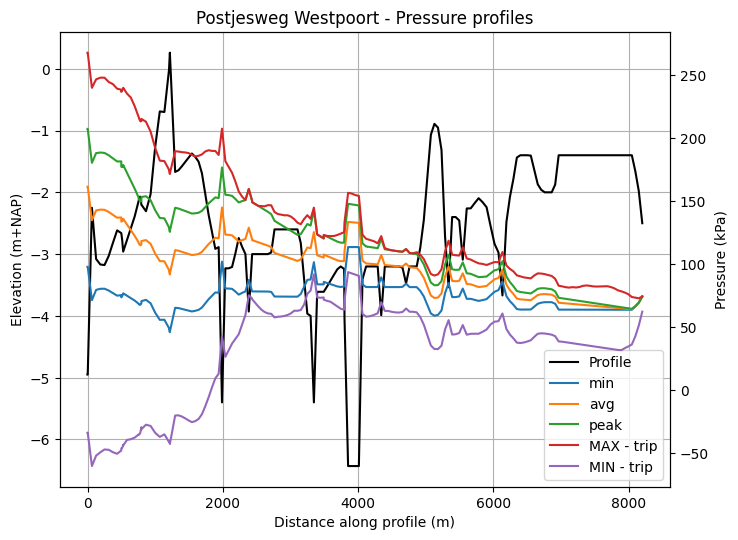

In [35]:
# Combine excel files
df_combined = df[['X', 'Y', 'Z', 's']]
legend_handles = []
plt.figure(figsize=(20/2.54, 15/2.54))
plt.grid()
ax1 = plt.gca()
legend_handles += (ax1.plot(df_combined['s'].values, df_combined['Z'].values, label='Profile', color='k'))
ax2 = ax1.twinx()
ax1.set_ylabel('Elevation (m+NAP)')
ax1.set_xlabel('Distance along profile (m)')
ax2.set_ylabel('Pressure (kPa)')
# ax1.legend(loc='upper right')
# ax2.legend(loc='upper left')
for case in cases:
    # Path to excel file
    excel_name = f"{datadir}{basename}_{case}.csv"
    # Load data
    df = pd.read_csv(excel_name)
    # Extract data
    if case != "trip":
        df_combined['P - {} (Pa)'.format(case)] = df['Pressure MAX (Pa)']
        legend_handles +=(ax2.plot(df_combined['s'].values, df['Pressure MAX (Pa)'] * 1E-3, label='{}'.format(case)))
    else:
        df_combined['P MIN- trip (Pa)'.format(case)] = df['Pressure MIN (Pa)']
        df_combined['P MAX- trip (Pa)'.format(case)] = df['Pressure MAX (Pa)']
        legend_handles += (ax2.plot(df_combined['s'].values, df['Pressure MAX (Pa)'] * 1E-3, label='MAX - {}'.format(case)))
        legend_handles +=(ax2.plot(df_combined['s'].values, df['Pressure MIN (Pa)'] * 1E-3, label='MIN - {}'.format(case)))

# print(legend_handles)
legend_labels = [l.get_label() for l in legend_handles]
ax1.legend(legend_handles, legend_labels, loc=0)
plt.title('Postjesweg Westpoort - Pressure profiles')
plt.savefig(f"{datadir}Postjesweg_pressure_profiles.png", dpi=300, bbox_inches='tight')

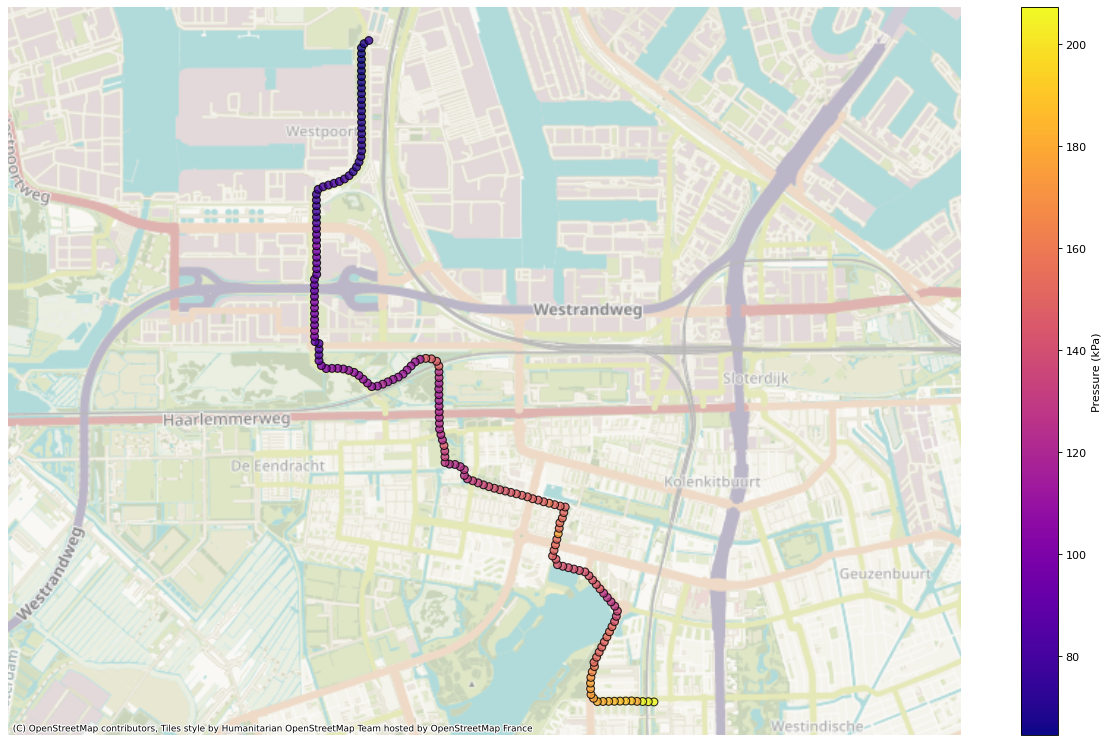

In [34]:
import geopandas as gpd
import contextily as cx
import shapely.geometry 
import matplotlib as mpl

plt.close('all')


gdf_result = gpd.GeoDataFrame(df_combined, geometry=df_combined.apply(lambda r: shapely.geometry.Point(r.X,r.Y,r.Z), axis=1))
gdf_result.crs = "EPSG:28992"

gdf_wm = gdf_result.to_crs(epsg=3857)
gdf_wm["P - peak (kPa)"] = gdf_wm["P - peak (Pa)"] *1e-3

plt.figure(figsize=(50/2.54, 30/2.54), dpi=80)
ax1 = plt.gca()

cmap = mpl.colormaps['plasma'].with_extremes(under='red')
gdf_wm.plot(ax=ax1, kind="geo", column="P - peak (kPa)", label="P - peak (kPa)",cmap= cmap, alpha=0.8, edgecolor="k", markersize=50, 
            legend=True, legend_kwds={"label": "Pressure (kPa)", "orientation": "vertical"})
ax1.set_axis_off()
ax1.set_xlim(gdf_wm.total_bounds[0]-4000, gdf_wm.total_bounds[2]+4000)
cx.add_basemap(ax1, alpha=0.7)
plt.savefig(f"{datadir}Postjesweg_avg_pressure.png", dpi=300, bbox_inches='tight')

In [8]:
print(gdf_wm.total_bounds)

[ 533754.69897158 6866181.00595076  538186.12165033 6874814.03759403]
